In [1]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Change directory to the project root so that we can
# refer to in-house package as "src".
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# from sklearn.model_selection import train_test_split

# Clean package imports from the src/ directory
from src.data_loader import load_and_merge_data
from src.preprocessor import DataPreprocessor
from src.walmart_dataset import WalmartDataset
from src.sales_predictor import SalesPredictor

# Define a function to set the seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # If CUDA is available, make sure to set the seed for it too.
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Force deterministic C++ and CUDA libraries to execute deterministically.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False 

set_seed(123)
print("Package imports and random seeds successfully initialized!")

Package imports and random seeds successfully initialized!


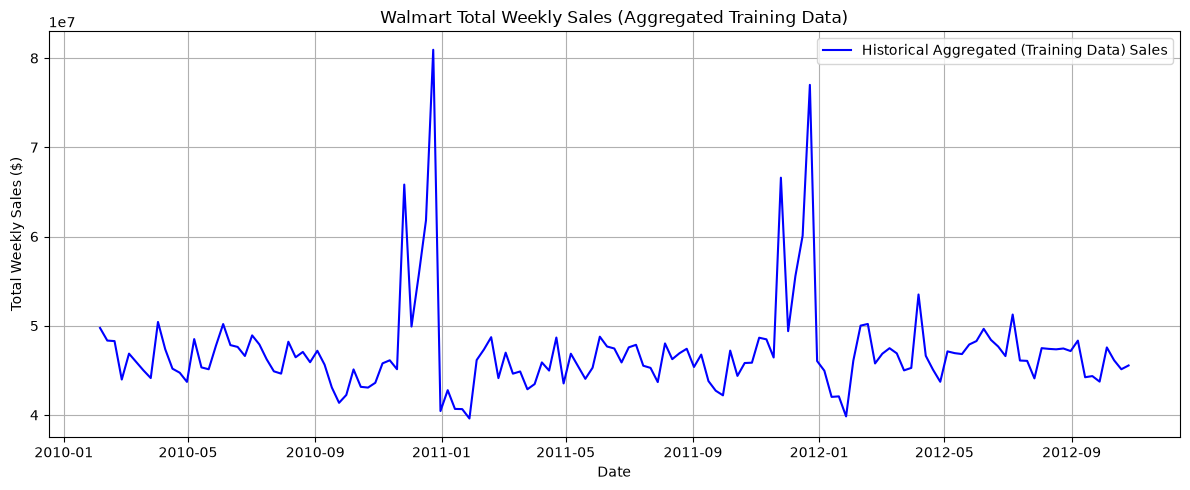

In [2]:
# Load the raw merged data frame.
df = load_and_merge_data('data')

# Sort the data chronologically to maintain time-series continuity.
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Visualize the sales data in the dataframe
train_agg = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(train_agg['Date'], train_agg['Weekly_Sales'], label='Historical Aggregated (Training Data) Sales', color='blue')
plt.title('Walmart Total Weekly Sales (Aggregated Training Data)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
# Split train.csv chronologically to create a train and validation set.
train_df = df[df['Date'].dt.year < 2012]
val_df = df[df['Date'].dt.year == 2012]

# Pre-process and scale features
preprocessor = DataPreprocessor()

# Fit and transform only on data from 2010-2011
x_train, y_train = preprocessor.fit_transform(train_df)
# Only transform applied to 2012 validation data 
x_val, y_val = preprocessor.transform(val_df)

# Wrap the data in a PyTorch Dataset and Dataloader for batch training
train_set = WalmartDataset(x_train, y_train)
val_set = WalmartDataset(x_val, y_val)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)

# Initialize the model
model = SalesPredictor(x_train.shape[1])

# Define the loss function and create the optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # For simplicity, using Adam as the optimizer.

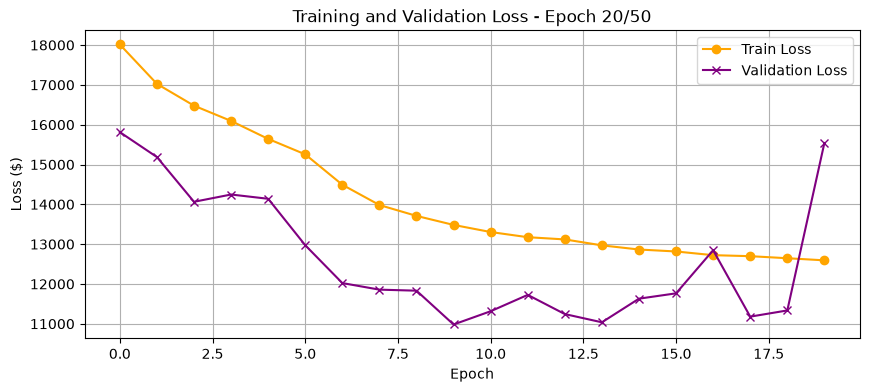


Early stopping now! Validation loss has not improved for 10 epochs.
Best model weights restored. Onto testing...


In [ ]:
# Training configurations.
epochs = 50
patience = 10 # Patience before early stopping.
best_val_loss = float('inf')
early_stopping_counter = 0

# For showing live and interactive results
plt.ion()
train_losses_history = []
val_losses_history = [] 

# Training loop
for epoch in range(epochs):
    # Training phase.
    model.train()
    train_loss = 0.0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Reset gradients.
        optimizer.zero_grad()

        # Forward pass through the model.
        predictions = model(inputs)

        # Compute the loss
        loss = criterion(predictions, targets)

        # Backward pass (to compute the gradients).
        loss.backward()

        # Optimizer step (to update the model parameters).
        optimizer.step()

        # Accumulate the batch loss
        train_loss += loss.item() * inputs.size(0)

    train_loss_scaled = train_loss / len(train_loader.dataset)
    # Real error. Apply an inverse transform to display real-world dollar
    # amount error (via preprocessor.y_scaler).
    real_train_error = train_loss_scaled * preprocessor.y_scaler.scale_[0]

    # Validation phase
    model.eval()
    val_loss = 0.0

    # Disable gradient computations for validation to save on memory and computations.
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss_scaled = val_loss / len(val_loader.dataset)
    real_val_error = val_loss_scaled * preprocessor.y_scaler.scale_[0]

    # print(f"Epoch {epoch+1}/epochs | Train loss: ${real_train_error:.2f} | Validation loss: ${real_val_error}")

    train_losses_history.append(real_train_error)
    val_losses_history.append(real_val_error)

    # Visualize the losses live
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses_history, label="Train Loss", color='orange', marker='o')
    ax.plot(val_losses_history, label='Validation Loss', color='purple', marker='x')
    ax.set_title(f'Training and Validation Loss - Epoch {epoch+1}/{epochs}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss ($)')
    ax.legend()
    ax.grid(True)
    plt.draw()
    plt.pause(0.01)

    # Early stopping check
    if real_val_error < best_val_loss:
        best_val_loss = real_val_error
        early_stopping_counter = 0
        # Save the best weights
        torch.save(model.state_dict(), 'saved_weights/best_model.pth')
    else:
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print(f"\nEarly stopping now! Validation loss has not improved for {patience} epochs.")    
        break # terminate the training loop

# Turn off interactive plot mode once training has concluded
plt.ioff()
plt.show()

# Load the best model weights back in before testing inference.
model.load_state_dict(torch.load('saved_weights/best_model.pth', weights_only=True))
print("Best model weights restored. Onto testing...")


Inference complete! Predictions saved to predictions.csv


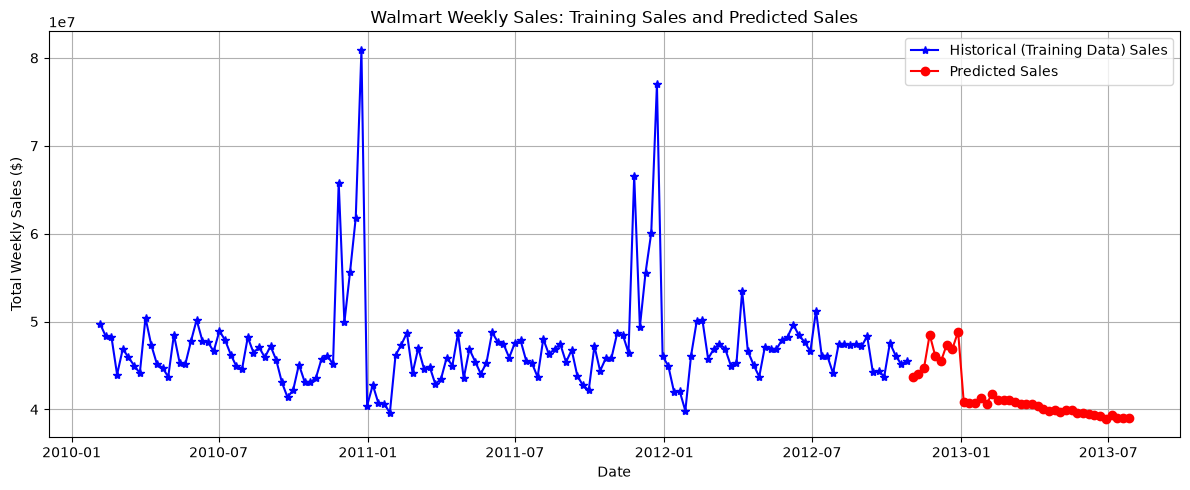

In [ ]:
# Load and merge the test data.
test_df = load_and_merge_data('data', is_test=True)
test_df['Date'] = pd.to_datetime(test_df['Date'])

# Inject a dummy target column to satisfy the preprocessor class requirements.txt
# This column is what we will fill via model inference.
test_df['Weekly_Sales'] = 0.0

# Pre-process the test data using the fitted preprocessor.
x_infer, _ = preprocessor.transform(test_df)

# Convert the data to a PyTorch tensor.
x_infer_tensor = torch.tensor(x_infer, dtype=torch.float32)

# Run inference
model.eval()
with torch.no_grad():
    scaled_predictions = model(x_infer_tensor).numpy()

# Inverse transform the predictions back to dollar values
real_predictions = preprocessor.y_scaler.inverse_transform(scaled_predictions)

# Format the output to a readable format
pred_df = pd.DataFrame({
    "Id": test_df['Store'].astype(str) + '_' + 
          test_df['Dept'].astype(str) + '_' + 
          test_df['Date'].astype(str),
    'Weekly_Sales': real_predictions.flatten()
})

# Export the predictions
pred_df.to_csv('predictions.csv', index=False)
print("Inference complete! Predictions saved to predictions.csv")

# Now show predicted test sales by date together with
# the sales from the training set.
test_with_date = test_df.copy()
test_with_date['Predicted_Sales'] = real_predictions.flatten()
test_agg = test_with_date.groupby('Date')['Predicted_Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(train_agg['Date'], train_agg['Weekly_Sales'], label='Historical (Training Data) Sales', color='blue', marker="*")
plt.plot(test_agg['Date'], test_agg['Predicted_Sales'], label='Predicted Sales', color='red', marker="o")
plt.title('Walmart Weekly Sales: Training Sales and Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

143
39
